# **RANSAC for Circle Fitting**

## 1. Setup and Synthetic Data Generation
We generate points along a circle's perimeter with some Gaussian noise, and add uniform random outliers.


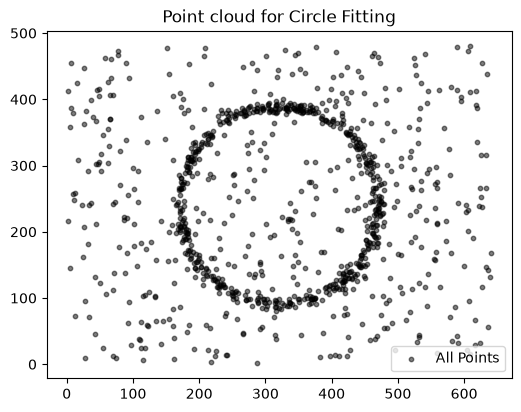

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_circle_data(N, center, radius, inlier_ratio=0.2):
    WIDTH, HEIGHT = 640, 480
    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []
    
    # Generate inliers along the circle perimeter with noise
    for _ in range(N_inlier):
        theta = random.random() * 2 * np.pi
        x = center[0] + radius * np.cos(theta) + np.random.normal(0, 5.0)
        y = center[1] + radius * np.sin(theta) + np.random.normal(0, 5.0)
        points.append([x, y])

    # Generate random outliers
    for _ in range(N_outlier):
        points.append([random.random() * WIDTH, random.random() * HEIGHT])

    return np.array(points, dtype=float)

init_random(seed=42)
N = 1000
true_center = (320.0, 240.0)
true_radius = 150.0
points = generate_circle_data(N, true_center, true_radius, inlier_ratio=0.5)

# Plot generated data
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(points[:,0], points[:,1], s=10, c='k', alpha=0.5, label='All Points')
ax.set_aspect('equal')
ax.set_title('Point cloud for Circle Fitting')
ax.legend()
plt.show()


## 2. RANSAC Algorithm -> 3 Points needed -> ($x^2 + y^2 + Dx + Ey + F = 0$).

$$
\underbrace{\begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ \vdots & \vdots & \vdots \end{bmatrix}}_{A}
\begin{bmatrix} D \\ E \\ F \end{bmatrix}
=
\begin{bmatrix} -(x_1^2 + y_1^2) \\ -(x_2^2 + y_2^2) \\ \vdots \end{bmatrix}
$$

In [ ]:
def fit_circle_3_points(p1, p2, p3):
    # Solve algebraic equation: x^2 + y^2 + D*x + E*y + F = 0
    # A * [D, E, F]^T = B
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ])

    B = np.array([
        -(p1[0]**2 + p1[1]**2),
        -(p2[0]**2 + p2[1]**2),
        -(p3[0]**2 + p3[1]**2)
    ])

    try:
        D, E, F = np.linalg.solve(A, B)

    except np.linalg.LinAlgError: # All on the same line -> NON UN CERCHIO
        return None  
    cx = -D / 2.0
    cy = -E / 2.0
    radius_sq = cx**2 + cy**2 - F

    if radius_sq < 0:
        return None
        
    return cx, cy, math.sqrt(radius_sq)

$$
d = \big\lvert \sqrt{(x - c_x)^2 + (y - c_y)^2} - r \big\rvert
$$

In [12]:

def distance_point_circle(circle_params, point):
    cx, cy, r = circle_params
    dist_to_center = math.sqrt((point[0] - cx)**2 + (point[1] - cy)**2)
    
    return abs(dist_to_center - r)

In [13]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

def ransac_circle(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    best_inliers_count = 0
    best_circle, best_inliers_list = None, []

    i = 0

    while i < max_iterations:
        idx = np.random.choice(len(points), 3, replace=False)
        circle_params = fit_circle_3_points(points[idx[0]], points[idx[1]], points[idx[2]])
        
        if circle_params is None:
            continue

        # Find inliers
        inliers = [pt for pt in points if distance_point_circle(circle_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count = len(inliers)
            best_circle = circle_params
            best_inliers_list = inliers
            # Adaptive iteration update
            max_iterations = min(max_iterations, iteration_number(confidence, 3, best_inliers_count, len(points)))

        i += 1

    return best_circle, np.array(best_inliers_list)


## 3. Results
Run RANSAC and visualize the best circle fit against the data.


True Circle: center=(320.0, 240.0), radius=150.0
RANSAC Circle: center=(317.8, 236.2), radius=149.8
Number of inliers: 488 out of 1000


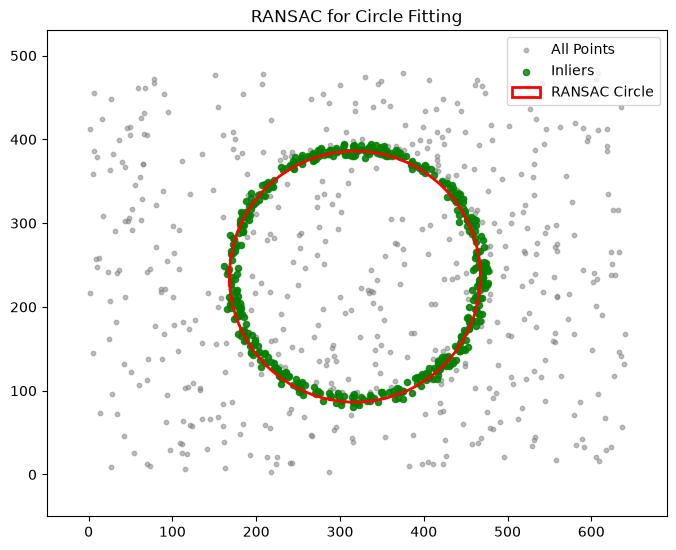

In [14]:
best_circle, inliers = ransac_circle(points)

print(f"True Circle: center={true_center}, radius={true_radius}")
if best_circle:
    print(f"RANSAC Circle: center=({best_circle[0]:.1f}, {best_circle[1]:.1f}), radius={best_circle[2]:.1f}")
    print(f"Number of inliers: {len(inliers)} out of {len(points)}")
else:
    print("Failed to find a valid circle.")

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(points[:,0], points[:,1], s=10, c='gray', alpha=0.5, label='All Points')
if best_circle:
    ax.scatter(inliers[:,0], inliers[:,1], s=20, c='green', alpha=0.8, label='Inliers')
    circle_plot = plt.Circle((best_circle[0], best_circle[1]), best_circle[2], color='red', fill=False, linewidth=2, label='RANSAC Circle')
    ax.add_patch(circle_plot)

ax.set_aspect('equal')
ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_title('RANSAC for Circle Fitting')
ax.legend()
plt.show()
